# Phase 2: Unsupervised Learning for Initial Detection (Anomaly-Based IDS)

# Task 2.1: Packet-Level Anomaly Detection

Build an unsupervised model that separates benign from non-benign packets.

## Setup, load metadata and sampled packet dataset

In [10]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    silhouette_score
)

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"

## load packet dataset and metadata
PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME
with open(META_PATH, "r") as f:
    metadata = json.load(f)
DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

## check class imbalance
BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"
print(df[BINARY_COL].value_counts())
print()
print(df[ATTACK_COL].value_counts())

## Create numeric labels for evaluation only
y_true = df[BINARY_COL].map({
    "benign": 0,
    "attack": 1
}).to_numpy()



(205041, 138)
binary_label
benign    200000
attack      5041
Name: count, dtype: int64

attack_type
Benign             200000
DNS Spoofing         3178
DDoS-HTTP Flood       833
Brute Force           404
DoS-HTTP Flood        364
XSS                   262
Name: count, dtype: int64


## K-Means

### K-Means Data feature selections:

K-Means is distance-based, so numeric feature scaling is required.<br>
Text fields such as IP addresses, MAC addresses, host names, and user agents should not be directly used.<br>
These labels are removed before training to avoid leakage.<br>

In [2]:
label_cols = [BINARY_COL, ATTACK_COL]

# These columns are identifiers or text-like fields, so do not use them for K-Means first.
drop_cols = [
    "src_ip", "dst_ip",
    "src_mac", "dst_mac",
    "device_mac",
    "eth_src_oui", "eth_dst_oui",
    "http_host", "http_uri", "http_content_type",
    "http_request_method", "user_agent",
    "dns_server", "tls_server",
    "highest_layer"
]

drop_cols = [col for col in drop_cols if col in df.columns]
label_cols = [col for col in label_cols if col in df.columns]

feature_df = df.drop(columns=label_cols + drop_cols)

numeric_cols = feature_df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
X_raw = feature_df[numeric_cols].copy()

print("Number of numeric features:", X_raw.shape[1])
X_raw.head()

Number of numeric features: 119


,stream,src_port,dst_port,inter_arrival_time,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,...,sum_p,min_p,max_p,med_p,average_p,var_p,q3_p,q1_p,iqr_p,l3_ip_dst_count
0,3308,38816,443,2109.894808,0.000185,1,1,0,64,60,...,3920.0,6.0,2908.0,12.0,196.00,423167.578947,19.0,12.0,7.0,9.0
1,7463,443,60200,4848.002092,0.000290,3,1,0,49,66,...,1173.0,12.0,387.0,15.5,58.65,10582.239474,32.0,12.0,20.0,9.0
2,3000,54061,443,1901.971732,0.003855,1,1,0,64,74,...,667.0,12.0,208.0,19.5,33.35,2097.081579,28.0,12.0,16.0,9.0
3,27,55444,55444,3902.830519,0.003104,3,0,1,64,60,...,360.0,18.0,18.0,18.0,18.00,0.000000,18.0,18.0,0.0,50.0
4,0,443,56891,23.178632,0.000001,3,1,0,231,66,...,24856.0,12.0,2908.0,1460.0,1242.80,502105.431579,1460.0,1460.0,0.0,3.0


### K-Means Basic preprocessing

Need to:<br>
&emsp;replace inf values<br>
&emsp;impute missing values with median<br>
&emsp;scale features<br>
&emsp;remove constant columns<br>

Missing and infinite values were replaced using median imputation because packet-level network features may contain undefined variance, jitter, or rate values. Constant columns were removed because they do not help clustering. Standard scaling was applied because K-Means uses Euclidean distance, and unscaled large-magnitude features would dominate the cluster assignment.

In [7]:
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

# Remove columns that are completely empty
X_raw = X_raw.dropna(axis=1, how="all")

# Remove constant columns
constant_cols = X_raw.columns[X_raw.nunique(dropna=True) <= 1]
X_raw = X_raw.drop(columns=constant_cols)

print("Features after cleaning:", X_raw.shape[1])

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = preprocess.fit_transform(X_raw)

print(X.shape)

Features after cleaning: 118
(205041, 118)


### Tune K-Means hyperparameter k

Using inertia and silhouette score<br>
Because silhouette score is expensive on 205k rows, calculate it on a smaller random subset.<br>

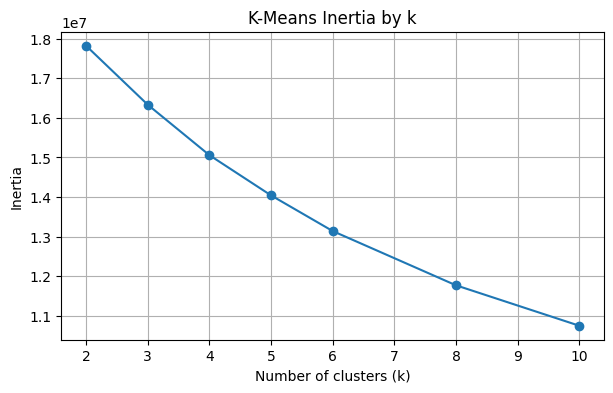

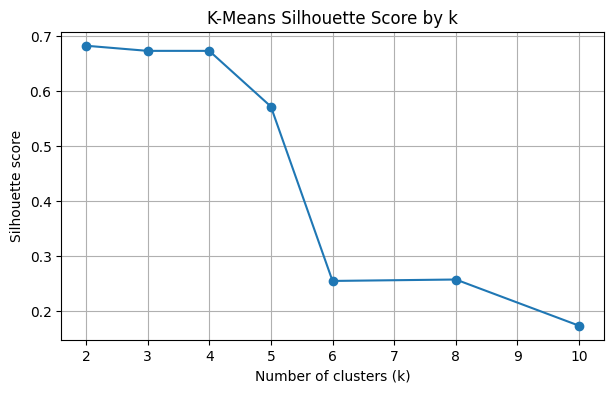

In [ ]:
k_values = [2, 3, 4, 5, 6, 8, 10]
tuning_results = []

## use random subset to save time
rng = np.random.default_rng(1)
sample_idx = rng.choice(X.shape[0], size=min(20000, X.shape[0]), replace=False)
X_sil = X[sample_idx]

for k in k_values:
    start = time.time()
    
    model = KMeans(
        n_clusters=k,
        random_state=1,
        n_init=10
    )
    labels = model.fit_predict(X)
    
    sil = silhouette_score(X_sil, labels[sample_idx])
    runtime = time.time() - start
    
    tuning_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_sample": sil,
        "runtime_sec": runtime
    })

kmeans_tuning_df = pd.DataFrame(tuning_results)
kmeans_tuning_df

plt.figure(figsize=(7, 4))
plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Inertia by k")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["silhouette_sample"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Score by k")
plt.grid(True)
plt.show()

For K-Means, the main hyperparameter I tuned is the number of clusters, k. Since this is an unsupervised model, I did not use the packet labels when choosing k. Instead, I compared different k values using two clustering-based measures: inertia and silhouette score.<br>

Inertia measures how close the data points are to their assigned cluster centers. A lower inertia usually means the clusters are more compact, but inertia will almost always decrease as k increases, so I used it mainly to look for an “elbow” point where the improvement starts to slow down.<br>

The silhouette score measures how well-separated the clusters are. A higher silhouette score means the clusters are more clearly separated. From the plot, the silhouette score is highest around k = 2 to k = 4, and it drops noticeably after k = 5. This suggests that using too many clusters may split the data into less meaningful groups.<br>

Based on both plots, I would choose **k = 4** as a reasonable starting value. It still has a high silhouette score, and the inertia has already improved compared with k = 2 and k = 3. I will use this value as the initial K-Means setting, then evaluate the anomaly detection performance using precision, recall, F1-score, FPR, FNR, AUC-ROC, and per-attack detection rate.<br>

### Train K-Means model

In [12]:
BEST_K = 4

start_train = time.time()

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=1,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

train_time = time.time() - start_train

print("Training time:", train_time)
print(pd.Series(cluster_labels).value_counts().sort_index())

Training time: 1.9807322025299072
0    189095
1         1
2      8690
3      7255
Name: count, dtype: int64


### K-Means Results

In [13]:
## Generate anomaly scores (distance from a packet to its nearest cluster center)
distances = kmeans.transform(X)
anomaly_score = distances.min(axis=1)

df_result = df.copy()
df_result["model"] = "KMeans"
df_result["cluster"] = cluster_labels
df_result["anomaly_score"] = anomaly_score

df_result[["cluster", "anomaly_score", BINARY_COL, ATTACK_COL]].head()

## Pick alert threshold
expected_attack_rate = metadata["total_attack_rows"] / metadata["total_rows"]

threshold = np.quantile(anomaly_score, 1 - expected_attack_rate)

df_result["y_pred"] = (df_result["anomaly_score"] >= threshold).astype(int)

print("Threshold:", threshold)
print(df_result["y_pred"].value_counts())

## Phase 2 metrics
def evaluate_binary_detection(y_true, y_pred, scores, model_name, runtime_sec):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    
    auc_roc = roc_auc_score(y_true, scores)
    avg_precision = average_precision_score(y_true, scores)
    
    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "auc_roc": auc_roc,
        "avg_precision": avg_precision,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "runtime_sec": runtime_sec
    }

metrics = evaluate_binary_detection(
    y_true=y_true,
    y_pred=df_result["y_pred"].to_numpy(),
    scores=df_result["anomaly_score"].to_numpy(),
    model_name="KMeans",
    runtime_sec=train_time
)

metrics_df = pd.DataFrame([metrics])
metrics_df

Threshold: 20.66514963651542
y_pred
0    200000
1      5041
Name: count, dtype: int64


,model,accuracy,precision,recall,f1,fpr,fnr,auc_roc,avg_precision,tp,fp,tn,fn,runtime_sec
0,KMeans,0.965782,0.304106,0.304106,0.304106,0.01754,0.695894,0.821286,0.226656,1533,3508,196492,3508,1.980732
